In [1]:
import os

proxy_url = 'http://127.0.0.1:7890'

def proxy_on():
    os.system('clash &')
    os.environ['http_proxy'] = proxy_url
    os.environ['https_proxy'] = proxy_url
    os.environ['all_proxy'] = proxy_url

# Disable proxy
def proxy_off():
    os.system('pkill clash')
    os.system('unset http_proxy')
    os.system('unset https_proxy')
    os.system('unset all_proxy')

proxy_on()

INFO[2026-03-16T17:44:01.32929802+08:00] Start initial configuration in progress      
INFO[2026-03-16T17:44:01.330452107+08:00] Geodata Loader mode: memconservative         
INFO[2026-03-16T17:44:01.330467743+08:00] Geosite Matcher implementation: succinct     
INFO[2026-03-16T17:44:01.331762512+08:00] Initial configuration complete, total time: 2ms 
ERRO[2026-03-16T17:44:01.332189505+08:00] External controller listen error: listen tcp 127.0.0.1:9090: bind: address already in use 
INFO[2026-03-16T17:44:01.35710726+08:00] Sniffer is closed                            
ERRO[2026-03-16T17:44:01.357270021+08:00] Start Mixed(http+socks) server error: listen tcp :7890: bind: address already in use 
WARN[2026-03-16T17:44:02.312476994+08:00] [CacheFile] can't open cache file: timeout   
INFO[2026-03-16T17:44:02.3158346+08:00] Start initial Compatible provider 性价比机场      
INFO[2026-03-16T17:44:02.315891345+08:00] Start initial Compatible provider default    
INFO[2026-03-16T17:44:02.315899932+0

## 使用DINO

In [2]:
from urllib.request import urlopen
from PIL import Image
import timm
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import torch
from timm.models._helpers import load_checkpoint

os.environ['CUDA_VISIBLE_DEVICES'] = '1'
os.environ['HF_HUB_OFFLINE'] = '1'


# ckpt = '/home/cz/.cache/huggingface/hub/models--timm--vit_7b_patch16_dinov3.sat493m/snapshots/781bbc782edbd43bf040d3336fc3d7dc207583e6/model.safetensors'

model = timm.create_model(
    'vit_large_patch16_dinov3_qkvb.sat493m',
    # 'vit_7b_patch16_dinov3.sat493m',
    pretrained=True,
    features_only=True,
    # checkpoint_path=ckpt,
    out_indices=(-4, -3, -2, -1), 
    # 注意：这里指向 snapshots 下的具体版本目录
).half().eval()
model = model.cuda()
model


/home/cz/anaconda3/envs/mm/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
'(MaxRetryError("HTTPSConnectionPool(host='huggingface.co', port=443): Max retries exceeded with url: /timm/vit_large_patch16_dinov3_qkvb.sat493m/resolve/main/model.safetensors (Caused by SSLError(SSLEOFError(8, '[SSL: UNEXPECTED_EOF_WHILE_READING] EOF occurred in violation of protocol (_ssl.c:1017)')))"), '(Request ID: 3b384651-5bad-4c8c-9eaa-8f79d05a6a61)')' thrown while requesting HEAD https://huggingface.co/timm/vit_large_patch16_dinov3_qkvb.sat493m/resolve/main/model.safetensors
Retrying in 1s [Retry 1/5].
'(MaxRetryError("HTTPSConnectionPool(host='huggingface.co', port=443): Max retries exceeded with url: /timm/vit_large_patch16_dinov3_qkvb.sat493m/resolve/main/model.safetensors (Caused by SSLError(SSLEOFError(8, '[SSL: UNE

FeatureGetterNet(
  (model): Eva(
    (patch_embed): PatchEmbed(
      (proj): Conv2d(3, 1024, kernel_size=(16, 16), stride=(16, 16))
      (norm): Identity()
    )
    (pos_drop): Dropout(p=0.0, inplace=False)
    (rope): RotaryEmbeddingDinoV3()
    (norm_pre): Identity()
    (blocks): ModuleList(
      (0-23): 24 x EvaBlock(
        (norm1): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
        (attn): EvaAttention(
          (qkv): Linear(in_features=1024, out_features=3072, bias=False)
          (q_norm): Identity()
          (k_norm): Identity()
          (attn_drop): Dropout(p=0.0, inplace=False)
          (norm): Identity()
          (proj): Linear(in_features=1024, out_features=1024, bias=True)
          (proj_drop): Dropout(p=0.0, inplace=False)
        )
        (drop_path1): Identity()
        (norm2): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
        (mlp): Mlp(
          (fc1): Linear(in_features=1024, out_features=4096, bias=True)
          (act): GE

In [102]:
import timm
from torch import nn
import torch
from torch.nn.init import normal_
import math 
from timm.models.layers import DropPath, trunc_normal_
import torch.nn.functional as F
from torch.nn.init import constant_, xavier_uniform_
import logging
from functools import partial
import torch.utils.checkpoint as cp
# from ops.modules import MSDeformAttn
from mmcv.ops.multi_scale_deform_attn import MultiScaleDeformableAttention
# from torch.nn import Identity as MultiScaleDeformableAttention
from mmseg.utils.transformer import BaseTransformerLayer
from mmengine.config import ConfigDict

def get_reference_points(spatial_shapes, device):
    reference_points_list = []
    for lvl, (H_, W_) in enumerate(spatial_shapes):
        ref_y, ref_x = torch.meshgrid(
            torch.linspace(0.5, H_ - 0.5, H_, dtype=torch.float32, device=device),
            torch.linspace(0.5, W_ - 0.5, W_, dtype=torch.float32, device=device))
        ref_y = ref_y.reshape(-1)[None] / H_
        ref_x = ref_x.reshape(-1)[None] / W_
        ref = torch.stack((ref_x, ref_y), -1)
        reference_points_list.append(ref)
    reference_points = torch.cat(reference_points_list, 1)
    reference_points = reference_points[:, :, None]
    return reference_points


def deform_inputs(x):
    bs, c, h, w = x.shape
    spatial_shapes = torch.as_tensor([(h // 8, w // 8),
                                      (h // 16, w // 16),
                                      (h // 32, w // 32)],
                                     dtype=torch.long, device=x.device)
    level_start_index = torch.cat((spatial_shapes.new_zeros(
        (1,)), spatial_shapes.prod(1).cumsum(0)[:-1]))
    reference_points = get_reference_points([(h // 16, w // 16)], x.device)
    deform_inputs1 = [reference_points, spatial_shapes, level_start_index]

    spatial_shapes = torch.as_tensor([(h // 16, w // 16)], dtype=torch.long, device=x.device)
    level_start_index = torch.cat((spatial_shapes.new_zeros(
        (1,)), spatial_shapes.prod(1).cumsum(0)[:-1]))
    reference_points = get_reference_points([(h // 8, w // 8),
                                             (h // 16, w // 16),
                                             (h // 32, w // 32)], x.device)
    deform_inputs2 = [reference_points, spatial_shapes, level_start_index]

    return deform_inputs1, deform_inputs2


class ConvFFN(nn.Module):
    def __init__(self, in_features, hidden_features=None, out_features=None,
                 act_layer=nn.GELU, drop=0.):
        super().__init__()
        out_features = out_features or in_features
        hidden_features = hidden_features or in_features
        self.fc1 = nn.Linear(in_features, hidden_features)
        self.dwconv = DWConv(hidden_features)
        self.act = act_layer()
        self.fc2 = nn.Linear(hidden_features, out_features)
        self.drop = nn.Dropout(drop)

    def forward(self, x, H, W):
        x = self.fc1(x)
        x = self.dwconv(x, H, W)
        x = self.act(x)
        x = self.drop(x)
        x = self.fc2(x)
        x = self.drop(x)
        return x


class DWConv(nn.Module):
    def __init__(self, dim=768):
        super().__init__()
        self.dwconv = nn.Conv2d(dim, dim, 3, 1, 1, bias=True, groups=dim)

    def forward(self, x, H, W):
        B, N, C = x.shape
        n = N // 21
        x1 = x[:, 0:16 * n, :].transpose(1, 2).view(B, C, H * 2, W * 2).contiguous()
        x2 = x[:, 16 * n:20 * n, :].transpose(1, 2).view(B, C, H, W).contiguous()
        x3 = x[:, 20 * n:, :].transpose(1, 2).view(B, C, H // 2, W // 2).contiguous()
        x1 = self.dwconv(x1).flatten(2).transpose(1, 2)
        x2 = self.dwconv(x2).flatten(2).transpose(1, 2)
        x3 = self.dwconv(x3).flatten(2).transpose(1, 2)
        x = torch.cat([x1, x2, x3], dim=1)
        return x


class Extractor(nn.Module):
    def __init__(self, dim, num_heads=6, n_points=4, n_levels=1, deform_ratio=1.0,
                 with_cffn=True, cffn_ratio=0.25, drop=0., drop_path=0.,
                 norm_layer=partial(nn.LayerNorm, eps=1e-6), with_cp=False):
        super().__init__()
        self.query_norm = norm_layer(dim)
        self.feat_norm = norm_layer(dim)
        # self.attn = MultiScaleDeformableAttention(embed_dims=dim, num_levels=n_levels, num_heads=num_heads,
        #                          num_points=n_points, value_proj_ratio=deform_ratio)
        self.attn = BaseTransformerLayer(use_time_mlp=True, num_points=n_points, value_proj_ratio=deform_ratio,
                attn_cfgs=ConfigDict(
                    type='MultiScaleDeformableAttention',
                    embed_dims=dim,
                    num_levels=n_levels,
                    num_heads=num_heads,
                    dropout=0.),
                ffn_cfgs=ConfigDict(
                    type='FFN',
                    embed_dims=dim,
                    feedforward_channels=1024,
                    ffn_drop=0.,
                    act_cfg=ConfigDict(type='GELU')),
                operation_order=('cross_attn', 'norm', 'ffn', 'norm'))
        
        self.with_cffn = with_cffn
        self.with_cp = with_cp
        if with_cffn:
            self.ffn = ConvFFN(in_features=dim, hidden_features=int(dim * cffn_ratio), drop=drop)
            self.ffn_norm = norm_layer(dim)
            self.drop_path = DropPath(drop_path) if drop_path > 0. else nn.Identity()

    def forward(self, query, reference_points, feat, spatial_shapes, level_start_index, H, W):

        def _inner_forward(query, feat):

            # attn = self.attn(self.query_norm(query), reference_points,
            #                  self.feat_norm(feat), spatial_shapes,
            #                  level_start_index, None)
            attn = self.attn(self.query_norm(query), self.feat_norm(feat), self.feat_norm(feat),
                             reference_points = reference_points,
                             spatial_shapes = spatial_shapes,
                             level_start_index = level_start_index)
            query = query + attn

            if self.with_cffn:
                query = query + self.drop_path(self.ffn(self.ffn_norm(query.permute(1,0,2)), H, W)).permute(1,0,2)
            return query

        if self.with_cp and query.requires_grad:
            query = cp.checkpoint(_inner_forward, query, feat)
        else:
            query = _inner_forward(query, feat)

        return query


class Injector(nn.Module):
    def __init__(self, dim, num_heads=6, n_points=4, n_levels=1, deform_ratio=1.0,
                 norm_layer=partial(nn.LayerNorm, eps=1e-6), init_values=0., with_cp=False):
        super().__init__()
        self.with_cp = with_cp
        self.query_norm = norm_layer(dim)
        self.feat_norm = norm_layer(dim)
        # self.attn = MultiScaleDeformableAttention(embed_dims=dim, num_levels=n_levels, num_heads=num_heads,
        #                          num_points=n_points, value_proj_ratio=deform_ratio)
        self.attn = BaseTransformerLayer(use_time_mlp=True, num_points=n_points, value_proj_ratio=deform_ratio,
                attn_cfgs=ConfigDict(
                    type='MultiScaleDeformableAttention',
                    embed_dims=dim,
                    num_levels=n_levels,
                    num_heads=num_heads,
                    dropout=0.),
                ffn_cfgs=ConfigDict(
                    type='FFN',
                    embed_dims=dim,
                    feedforward_channels=1024,
                    ffn_drop=0.,
                    act_cfg=ConfigDict(type='GELU')),
                operation_order=('cross_attn', 'norm', 'ffn', 'norm'))
        self.gamma = nn.Parameter(init_values * torch.ones((dim)), requires_grad=True)

    def forward(self, query, reference_points, feat, spatial_shapes, level_start_index):

        def _inner_forward(query, feat):

            # attn = self.attn(self.query_norm(query), reference_points,
            #                  self.feat_norm(feat), spatial_shapes,
            #                  level_start_index, None)

            attn = self.attn(self.query_norm(query), self.feat_norm(feat), self.feat_norm(feat),
                    reference_points = reference_points,
                    spatial_shapes = spatial_shapes,
                    level_start_index = level_start_index)
            return query + self.gamma * attn

        if self.with_cp and query.requires_grad:
            query = cp.checkpoint(_inner_forward, query, feat)
        else:
            query = _inner_forward(query, feat)

        return query


class InteractionBlock(nn.Module):
    def __init__(self, dim, num_heads=6, n_points=4, norm_layer=partial(nn.LayerNorm, eps=1e-6),
                 drop=0., drop_path=0., with_cffn=True, cffn_ratio=0.25, init_values=0.,
                 deform_ratio=1.0, extra_extractor=False, with_cp=False):
        super().__init__()

        self.injector = Injector(dim=dim, n_levels=3, num_heads=num_heads, init_values=init_values,
                                 n_points=n_points, norm_layer=norm_layer, deform_ratio=deform_ratio,
                                 with_cp=with_cp)
        self.extractor = Extractor(dim=dim, n_levels=1, num_heads=num_heads, n_points=n_points,
                                   norm_layer=norm_layer, deform_ratio=deform_ratio, with_cffn=with_cffn,
                                   cffn_ratio=cffn_ratio, drop=drop, drop_path=drop_path, with_cp=with_cp)
        if extra_extractor:
            self.extra_extractors = nn.Sequential(*[
                Extractor(dim=dim, num_heads=num_heads, n_points=n_points, norm_layer=norm_layer,
                          with_cffn=with_cffn, cffn_ratio=cffn_ratio, deform_ratio=deform_ratio,
                          drop=drop, drop_path=drop_path, with_cp=with_cp)
                for _ in range(2)
            ])
        else:
            self.extra_extractors = None

    def forward(self, x, c, blocks, deform_inputs1, deform_inputs2, H, W, rot_pos_embed):
        x[:,5:] = self.injector(query=x[:,5:].permute(1,0,2), reference_points=deform_inputs1[0],
                          feat=c.permute(1,0,2), spatial_shapes=deform_inputs1[1],
                          level_start_index=deform_inputs1[2]).permute(1,0,2)
        for idx, blk in enumerate(blocks):
            x = blk(x, rope=rot_pos_embed)
        c = self.extractor(query=c.permute(1,0,2), reference_points=deform_inputs2[0],
                           feat=x[:,5:].permute(1,0,2), spatial_shapes=deform_inputs2[1],
                           level_start_index=deform_inputs2[2], H=H, W=W).permute(1,0,2)
        if self.extra_extractors is not None:
            for extractor in self.extra_extractors:
                c = extractor(query=c.permute(1,0,2), reference_points=deform_inputs2[0],
                              feat=x[:,5:].permute(1,0,2), spatial_shapes=deform_inputs2[1],
                              level_start_index=deform_inputs2[2], H=H, W=W).permute(1,0,2)
        return x, c
    
    

class SpatialPriorModule(nn.Module):
    def __init__(self, inplanes=64, embed_dim=384, with_cp=False):
        super().__init__()
        self.with_cp = with_cp

        self.stem = nn.Sequential(*[
            nn.Conv2d(3, inplanes, kernel_size=3, stride=2, padding=1, bias=False),
            nn.SyncBatchNorm(inplanes),
            nn.ReLU(inplace=True),
            nn.Conv2d(inplanes, inplanes, kernel_size=3, stride=1, padding=1, bias=False),
            nn.SyncBatchNorm(inplanes),
            nn.ReLU(inplace=True),
            nn.Conv2d(inplanes, inplanes, kernel_size=3, stride=1, padding=1, bias=False),
            nn.SyncBatchNorm(inplanes),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2, padding=1)
        ])
        self.conv2 = nn.Sequential(*[
            nn.Conv2d(inplanes, 2 * inplanes, kernel_size=3, stride=2, padding=1, bias=False),
            nn.SyncBatchNorm(2 * inplanes),
            nn.ReLU(inplace=True)
        ])
        self.conv3 = nn.Sequential(*[
            nn.Conv2d(2 * inplanes, 4 * inplanes, kernel_size=3, stride=2, padding=1, bias=False),
            nn.SyncBatchNorm(4 * inplanes),
            nn.ReLU(inplace=True)
        ])
        self.conv4 = nn.Sequential(*[
            nn.Conv2d(4 * inplanes, 4 * inplanes, kernel_size=3, stride=2, padding=1, bias=False),
            nn.SyncBatchNorm(4 * inplanes),
            nn.ReLU(inplace=True)
        ])
        self.fc1 = nn.Conv2d(inplanes, embed_dim, kernel_size=1, stride=1, padding=0, bias=True)
        self.fc2 = nn.Conv2d(2 * inplanes, embed_dim, kernel_size=1, stride=1, padding=0, bias=True)
        self.fc3 = nn.Conv2d(4 * inplanes, embed_dim, kernel_size=1, stride=1, padding=0, bias=True)
        self.fc4 = nn.Conv2d(4 * inplanes, embed_dim, kernel_size=1, stride=1, padding=0, bias=True)

    def forward(self, x):

        def _inner_forward(x):
            c1 = self.stem(x)
            c2 = self.conv2(c1)
            c3 = self.conv3(c2)
            c4 = self.conv4(c3)
            c1 = self.fc1(c1)
            c2 = self.fc2(c2)
            c3 = self.fc3(c3)
            c4 = self.fc4(c4)

            bs, dim, _, _ = c1.shape
            # c1 = c1.view(bs, dim, -1).transpose(1, 2)  # 4s
            c2 = c2.view(bs, dim, -1).transpose(1, 2)  # 8s
            c3 = c3.view(bs, dim, -1).transpose(1, 2)  # 16s
            c4 = c4.view(bs, dim, -1).transpose(1, 2)  # 32s

            return c1, c2, c3, c4

        if self.with_cp and x.requires_grad:
            outs = cp.checkpoint(_inner_forward, x)
        else:
            outs = _inner_forward(x)
        return outs


In [127]:
class DINOAdapter(nn.Module):
    def __init__(
        self,
        eva,
        embed_dim=1024,
        init_values=1e-6,
        drop_path_rate=0.3,
        conv_inplane=64,
        n_points=4,
        deform_num_heads=16,
        cffn_ratio=0.25,
        deform_ratio=0.5,
        with_cp=True,  # set with_cp=True to save memory
        interaction_indexes=[[0, 5], [6, 11], [12, 17], [18, 23]],
        with_cffn=True,
        add_vit_feature=True
    ):
        super().__init__()
        self.eva = eva
        self.spm = SpatialPriorModule(inplanes=conv_inplane, embed_dim=embed_dim, with_cp=False)
        self.level_embed = nn.Parameter(torch.zeros(3, embed_dim))
        self.interactions = nn.Sequential(*[
            InteractionBlock(dim=embed_dim, num_heads=deform_num_heads, n_points=n_points,
                             init_values=init_values, drop_path=drop_path_rate,
                             with_cffn=with_cffn,
                             cffn_ratio=cffn_ratio, deform_ratio=deform_ratio,
                             extra_extractor=True if i == len(interaction_indexes) - 1 else False,
                             with_cp=with_cp)
            for i in range(len(interaction_indexes))
        ])
        self.interaction_indexes = interaction_indexes
        self.add_vit_feature = add_vit_feature
        self.up = nn.ConvTranspose2d(embed_dim, embed_dim, 2, 2)
        self.norm1 = nn.SyncBatchNorm(embed_dim)
        self.norm2 = nn.SyncBatchNorm(embed_dim)
        self.norm3 = nn.SyncBatchNorm(embed_dim)
        self.norm4 = nn.SyncBatchNorm(embed_dim)

        self.up.apply(self._init_weights)
        self.spm.apply(self._init_weights)
        self.interactions.apply(self._init_weights)
        self.apply(self._init_deform_weights)
        normal_(self.level_embed)
        
    # def _init_deform_weights(self, m):
    #     if isinstance(m, MultiScaleDeformableAttention):
    #         m._reset_parameters()
    def _init_deform_weights(self, m):
        if not isinstance(m, MultiScaleDeformableAttention):
            return
        constant_(m.sampling_offsets.weight.data, 0.)
        thetas = torch.arange(
            m.num_heads, dtype=torch.float32) * (2.0 * math.pi / m.num_heads)
        grid_init = torch.stack([thetas.cos(), thetas.sin()], -1)
        grid_init = (grid_init / grid_init.abs().max(-1, keepdim=True)[0]).view(
                         m.num_heads, 1, 1, 2).repeat(1, m.num_levels, m.num_points, 1)
        for i in range(m.num_points):
            grid_init[:, :, i, :] *= i + 1

        with torch.no_grad():
            m.sampling_offsets.bias = nn.Parameter(grid_init.view(-1))
        constant_(m.attention_weights.weight.data, 0.)
        constant_(m.attention_weights.bias.data, 0.)
        xavier_uniform_(m.value_proj.weight.data)
        constant_(m.value_proj.bias.data, 0.)
        xavier_uniform_(m.output_proj.weight.data)
        constant_(m.output_proj.bias.data, 0.)
            
    def _init_weights(self, m):
        if isinstance(m, nn.Linear):
            trunc_normal_(m.weight, std=.02)
            if isinstance(m, nn.Linear) and m.bias is not None:
                nn.init.constant_(m.bias, 0)
        elif isinstance(m, nn.LayerNorm) or isinstance(m, nn.BatchNorm2d):
            nn.init.constant_(m.bias, 0)
            nn.init.constant_(m.weight, 1.0)
        elif isinstance(m, nn.Conv2d) or isinstance(m, nn.ConvTranspose2d):
            fan_out = m.kernel_size[0] * m.kernel_size[1] * m.out_channels
            fan_out //= m.groups
            m.weight.data.normal_(0, math.sqrt(2.0 / fan_out))
            if m.bias is not None:
                m.bias.data.zero_()
    
    def _add_level_embed(self, c2, c3, c4):
        c2 = c2 + self.level_embed[0]
        c3 = c3 + self.level_embed[1]
        c4 = c4 + self.level_embed[2]
        return c2, c3, c4
    
    def dino_forward(self, x):
        # forward pass
        B, _, height, width = x.shape
        x = self.eva.patch_embed(x)
        x, rot_pos_embed = self.eva._pos_embed(x)
        x = self.eva.norm_pre(x)
        
        intermediates = []
        
        for i, blk in enumerate(self.eva.blocks):
            x = blk(x, rope=rot_pos_embed)
            intermediates.append(x)
        
        intermediates = [y[:, self.eva.num_prefix_tokens:] for y in intermediates]
            # reshape to BCHW output format
        H, W = self.eva.patch_embed.dynamic_feat_size((height, width))
        intermediates = [y.reshape(B, H, W, -1).permute(0, 3, 1, 2).contiguous() for y in intermediates]

        return intermediates
    
    def forward(self, x):
        deform_inputs1, deform_inputs2 = deform_inputs(x)

        # SPM forward
        c1, c2, c3, c4 = self.spm(x)
        c2, c3, c4 = self._add_level_embed(c2, c3, c4)
        c = torch.cat([c2, c3, c4], dim=1)
        
        # Patch Embedding forward
        x = self.eva.patch_embed(x)
        H, W = x.shape[1:3]
        bs, n, dim = x.shape[0], H*W, x.shape[-1]
        
        x, rot_pos_embed = self.eva._pos_embed(x)
        x = self.eva.norm_pre(x)
        
        # Interaction
        outs = list()
        for i, layer in enumerate(self.interactions):
            indexes = self.interaction_indexes[i]
            x, c = layer(x, c, self.eva.blocks[indexes[0]:indexes[-1] + 1],
                              deform_inputs1, deform_inputs2, H, W, rot_pos_embed)
            outs.append(x[:,5:].transpose(1, 2).view(bs, dim, H, W).contiguous())
        # return outs
        # Split & Reshape
        c2 = c[:, 0:c2.size(1), :]
        c3 = c[:, c2.size(1):c2.size(1) + c3.size(1), :]
        c4 = c[:, c2.size(1) + c3.size(1):, :]

        c2 = c2.transpose(1, 2).view(bs, dim, H * 2, W * 2).contiguous()
        c3 = c3.transpose(1, 2).view(bs, dim, H, W).contiguous()
        c4 = c4.transpose(1, 2).view(bs, dim, H // 2, W // 2).contiguous()
        c1 = self.up(c2) + c1

        if self.add_vit_feature:
            x1, x2, x3, x4 = outs
            x1 = F.interpolate(x1, scale_factor=4, mode='bilinear', align_corners=False)
            x2 = F.interpolate(x2, scale_factor=2, mode='bilinear', align_corners=False)
            x4 = F.interpolate(x4, scale_factor=0.5, mode='bilinear', align_corners=False)
            c1, c2, c3, c4 = c1 + x1, c2 + x2, c3 + x3, c4 + x4

        # Final Norm
        f1 = self.norm1(c1)
        f2 = self.norm2(c2)
        f3 = self.norm3(c3)
        f4 = self.norm4(c4)
        return [f1, f2, f3, f4]

In [128]:
dino_adapter = DINOAdapter(
        eva = model.model,
        embed_dim=1024,
        init_values=1e-6,
        drop_path_rate=0.3,
        conv_inplane=64,
        n_points=4,
        deform_num_heads=16,
        cffn_ratio=0.25,
        deform_ratio=0.5,
        with_cp=True,  # set with_cp=True to save memory
        interaction_indexes=[[0, 5], [6, 11], [12, 17], [18, 23]],
    ).half().cuda()

x = torch.randn(1,3,512,512).half().cuda()
output = dino_adapter.dino_forward(x)

In [121]:
output_timm = model(x)  # unsqueeze single image into batch of 1
len(output),len(output_timm)

(24, 4)

In [122]:
(output[-1] == output_timm[-1]).all(),(output[-2] == output_timm[-2]).all(),\
    (output[-3] == output_timm[-3]).all(),(output[-4] == output_timm[-4]).all()

(tensor(True, device='cuda:0'),
 tensor(True, device='cuda:0'),
 tensor(True, device='cuda:0'),
 tensor(True, device='cuda:0'))

In [129]:
output_adapter = dino_adapter(x)

/home/cz/anaconda3/envs/mm/lib/python3.10/site-packages/torch/utils/checkpoint.py:429: UserWarning: torch.utils.checkpoint: please pass in use_reentrant=True or use_reentrant=False explicitly. The default value of use_reentrant will be updated to be False in the future. To maintain current behavior, pass use_reentrant=True. It is recommended that you use use_reentrant=False. Refer to docs for more details on the differences between the two variants.
  warnings.warn(


In [130]:
for _ in output_adapter:
    print(_.shape)

torch.Size([1, 1024, 128, 128])
torch.Size([1, 1024, 64, 64])
torch.Size([1, 1024, 32, 32])
torch.Size([1, 1024, 16, 16])


In [ ]:
# get model specific transforms (normalization, resize)
data_config = timm.data.resolve_model_data_config(model)
transforms = timm.data.create_transform(**data_config, is_training=False)

def transform(path):
    img = cv2.cvtColor(cv2.imread(path), cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (50 * 16, 50 * 16)) / 255
    img = (img - np.array([0.43, 0.411, 0.296]))/ np.array([0.213, 0.156, 0.143])
    img = img.transpose(2, 0, 1)
    return np.expand_dims(img, 0).astype(np.float32)

### show image

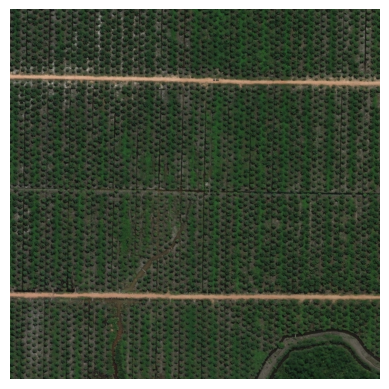

In [12]:
ori_img = cv2.cvtColor(cv2.imread('/data1/datasets/zhengbo/roaddataset/deepglobe/images/train/100081.jpg'),cv2.COLOR_BGR2RGB)
plt.imshow(ori_img)
plt.axis("off")
plt.show()

In [13]:
img = transform('/data1/datasets/zhengbo/roaddataset/deepglobe/images/train/100081.jpg')
print(img.shape)

output = model(torch.from_numpy(img).half().cuda())  # unsqueeze single image into batch of 1

for o in output:
    print(o.shape)

(1, 3, 800, 800)
torch.Size([1, 1024, 50, 50])
torch.Size([1, 1024, 50, 50])
torch.Size([1, 1024, 50, 50])
torch.Size([1, 1024, 50, 50])


In [14]:
print(model.feature_info)
print("channels:", model.feature_info.channels())
print("reductions:", model.feature_info.reduction())
print("module names:", model.feature_info.module_name())

channels: [1024, 1024, 1024, 1024]
reductions: [16, 16, 16, 16]
module names: ['blocks.20', 'blocks.21', 'blocks.22', 'blocks.23']


### 特征聚类

In [15]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import MinMaxScaler, StandardScaler

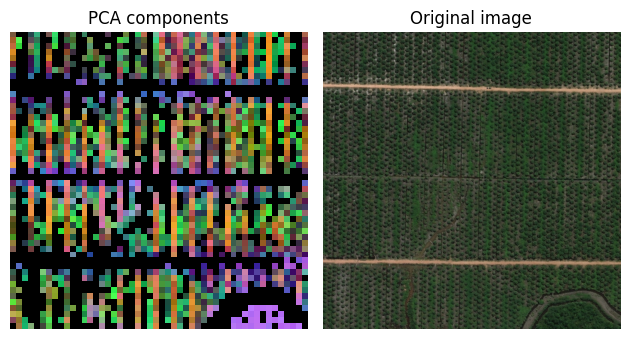

In [16]:
patch_features = output[-1][0].permute(1,2,0).reshape(-1,1024).cpu().detach().numpy()
background_threshold = 0.5


pca = PCA(n_components=3)
scaler = MinMaxScaler(clip=True)

# First fit to seperate background and foreground
pca.fit(patch_features)
pca_features = pca.transform(patch_features)

# MinMax Scaling
scaler.fit(pca_features)
pca_features = scaler.transform(pca_features)

# Sometimes the predictions might come out slightly changed
# you can play with the threshold to improve the outcome.
pca_background = pca_features[:, 0] > background_threshold
pca_foreground = ~pca_background

# Second fit for the object
pca.fit(patch_features[pca_foreground])
pca_features_rem = pca.transform(patch_features[pca_foreground])

scaler.fit(pca_features_rem)
pca_features_rem = scaler.transform(pca_features_rem)

pca_features_rgb = np.zeros((50*50, 3))
pca_features_rgb[pca_background] = 0
pca_features_rgb[pca_foreground] = pca_features_rem
pca_features_rgb = pca_features_rgb.reshape(50, 50, 3)

plt.figure()
plt.subplot(121)
plt.imshow(pca_features_rgb)
plt.title(f"PCA components")
plt.axis("off")
# Plot original images
plt.subplot(122)
plt.imshow(ori_img)
plt.title(f"Original image")
plt.axis("off")

plt.tight_layout()
plt.show()

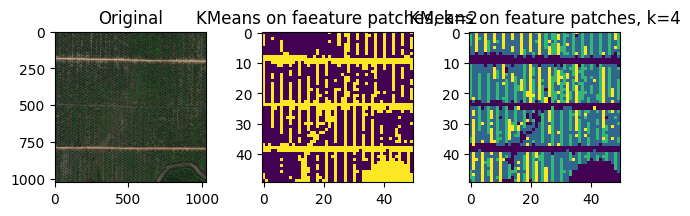

INFO[2026-03-03T17:31:16.903744594+08:00] [TCP] 172.20.84.5:60534 --> www.google.com:443 match DomainKeyword(google) using 性价比机场[🇺🇸 美国1] 
INFO[2026-03-03T17:31:16.913742286+08:00] [TCP] 172.20.84.5:60522 --> www.google.com:443 match DomainKeyword(google) using 性价比机场[🇺🇸 美国1] 
INFO[2026-03-03T17:37:18.516835692+08:00] [TCP] 127.0.0.1:51454 --> huggingface.co:443 match Match using 性价比机场[🇺🇸 美国1] 
INFO[2026-03-03T17:37:20.142369483+08:00] [TCP] 127.0.0.1:51748 --> huggingface.co:443 match Match using 性价比机场[🇺🇸 美国1] 
INFO[2026-03-03T17:39:51.186299823+08:00] [TCP] 127.0.0.1:48732 --> huggingface.co:443 match Match using 性价比机场[🇺🇸 美国1] 
INFO[2026-03-03T17:41:19.286260304+08:00] [TCP] 127.0.0.1:59408 --> huggingface.co:443 match Match using 性价比机场[🇺🇸 美国1] 
INFO[2026-03-03T17:44:45.838864366+08:00] [TCP] 127.0.0.1:53930 --> huggingface.co:443 match Match using 性价比机场[🇺🇸 美国1] 
INFO[2026-03-03T17:47:04.860699474+08:00] [TCP] 172.20.84.5:38708 --> www.google.com:443 match DomainKeyword(google) using 性

In [17]:
raw_scaled = StandardScaler().fit_transform(patch_features)

labels_k3 = KMeans(n_clusters=2, random_state=0, n_init=10).fit_predict(raw_scaled).reshape(50, 50)
labels_k5 = KMeans(n_clusters=4, random_state=0, n_init=10).fit_predict(raw_scaled).reshape(50, 50)

plt.figure()
plt.subplot(131)
plt.imshow(ori_img)
plt.title("Original")

plt.subplot(132)
plt.imshow(labels_k3)
plt.title("KMeans on faeature patches, k=2")

plt.subplot(133)
plt.imshow(labels_k5)
plt.title("KMeans on feature patches, k=4")

    
plt.tight_layout()
plt.show()

## Finetuned-DINO

In [2]:
import torch
import matplotlib.pyplot as plt
from mmengine.model.utils import revert_sync_batchnorm
from mmseg.apis import init_model, inference_model, show_result_pyplot


config_file = '/data/openclaw/segsRoad/configs/dino/deep_dino_comer_mask2former.py'
checkpoint_file = '/data/openclaw/segsRoad/work_dirs/deep_dino_comer_mask2former/best_mIoU_iter_160000.pth'

/data/openclaw/segsRoad/.venv/lib/python3.10/site-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
/data/openclaw/segsRoad/.venv/lib/python3.10/site-packages/timm/models/registry.py:4: FutureWarning: Importing from timm.models.registry is deprecated, please import via timm.models
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.models", FutureWarning)
/data/openclaw/segsRoad/.venv/lib/python3.10/site-packages/timm/models/helpers.py:7: FutureWarning: Importing from timm.models.helpers is deprecated, please import via timm.models
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.models", FutureWarning)


/data/openclaw/segsRoad/vim


/data/openclaw/segsRoad/mmseg/models/backbones/localvmamba.py:29: UserWarning: No module named 'selective_scan_cuda_core'
"selective_scan_cuda_core" not found, use default "selective_scan_cuda" instead.
  warnings.warn(f"{e}\n\"selective_scan_cuda_core\" not found, use default \"selective_scan_cuda\" instead.")


In [3]:
import os
os.environ['CUDA_VISIBLE_DEVICES'] = '1'
model = init_model(config_file, checkpoint_file, device='cuda:0')

backbone: {'total_params': 389183552, 'trainable_params': 86057024, 'frozen_params': 303126528, 'trainable_ratio': 0.22112194505075075, 'frozen_ratio': 0.7788780549492492, 'trainable_tensors': 433, 'frozen_tensors': 364}
Loads checkpoint by local backend from path: /data/openclaw/segsRoad/work_dirs/deep_dino_comer_mask2former/best_mIoU_iter_160000.pth


In [4]:
# test a single image
img = '/data1/datasets/zhengbo/roaddataset/deepglobe/images/val/70933.jpg'
if not torch.cuda.is_available():
    model = revert_sync_batchnorm(model)
result = inference_model(model, img)
output = result.get('seg_logits').data.softmax(dim=0)[1]
output.shape

/data/openclaw/segsRoad/.venv/lib/python3.10/site-packages/torch/functional.py:504: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at ../aten/src/ATen/native/TensorShape.cpp:3526.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


torch.Size([1024, 1024])

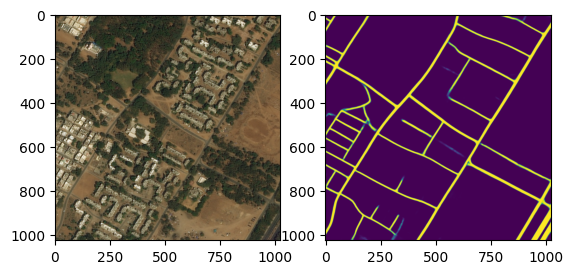

In [5]:
input_image = plt.imread(img)
plt.subplot(121)
plt.imshow(input_image)
plt.subplot(122)
plt.imshow(output.cpu().detach().numpy())
plt.show()

In [6]:
img = '/data1/datasets/zhengbo/roaddataset/deepglobe/images/val/70933.jpg'
img = plt.imread(img)
imgs = [img[:512,:512], img[512:,:512], img[:512,512:], img[512:,512:]]
for _, img in enumerate(imgs):
    plt.imsave(f'{_}.jpg',img)
if not torch.cuda.is_available():
    model = revert_sync_batchnorm(model)

outputs = []
for i in range(4):
    result = inference_model(model, f'{i}.jpg')
    output = result.get('seg_logits').data.softmax(dim=0)[1]
    outputs.append(output)

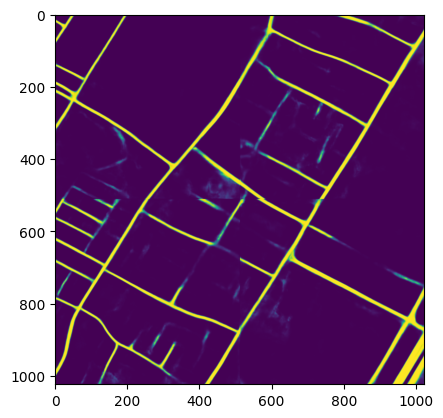

In [8]:
import numpy as np
outputs_show = np.zeros((1024,1024))
outputs_show[:512,:512] = outputs[0].cpu().detach().numpy()
outputs_show[512:,:512] = outputs[1].cpu().detach().numpy()
outputs_show[:512,512:] = outputs[2].cpu().detach().numpy()
outputs_show[512:,512:] = outputs[3].cpu().detach().numpy()

plt.imshow(outputs_show)
plt.show()